# 03 — Monte Carlo Simulation: Federal Revenue Shortfall Under AI Displacement

**Takes in:** `data/02_merged_clean.csv` — cleaned, merged dataframe with IRS SOI financials and Digital Planet AI exposure metrics (industry-year level)  
**Does:** Runs N-iteration Monte Carlo simulations per industry across Slow/Median/Fast AI adoption timelines; aggregates to federal totals; identifies deficit-trap thresholds  
**Outputs:** `output/03_simulation_results.csv`, `output/03_deficit_trap_summary.csv`, simulation distribution figures

## 0. Imports and display settings

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

np.random.seed(42)

## 1. Config — paths and simulation parameters

In [18]:
# --- Paths (relative; no hardcoded user directories) ---
INPUT_PATH  = os.path.join("data", "02_merged_clean.csv")
OUTPUT_DIR  = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Simulation parameters ---
N_ITERATIONS = 100_000  # Increased for greater tail accuracy
NOISE_STD    = 0.05     # std dev of proportional lognormal shock to income-loss rates

# --- Column names (never hardcoded by position) ---
COL_INDUSTRY   = "Industry_std"
COL_IND_TYPE   = "Industry_IRS"

# IRS baseline fiscal columns (from 02_merged_clean)
COL_WAGES      = "IRS_Salaries_Wages"          # total wage base ($)
COL_CORP_NET   = "IRS_Net_Income_Less_Deficit"   # corporate net income ($)

# Digital Planet income-loss rate columns (percent, 0–1 scale)
TIMELINE_COLS = {
    "Slow":   "Job and Income Loss: Slowest Time Progression - Percent Income Loss",
    "Median": "Job and Income Loss: Median Time Progression - Percent Income Loss",
    "Fast":   "Job and Income Loss: Fastest Time Progression - Percent Income Loss",
}

# Effective federal tax rates applied to each base (approximate statutory proxies)
PAYROLL_TAX_RATE = 0.153   # combined employer + employee FICA rate
INCOME_TAX_RATE  = 0.22    # approximate effective individual income-tax rate on wages
CORP_TAX_RATE    = 0.21    # statutory corporate rate

# Corporate income growth assumption to partially offset labor loss
CORP_GROWTH_RATE = 0.03    # 3% annual growth in corporate net income

# Deficit-trap threshold: shortfall fraction of current total revenue
DEFICIT_TRAP_THRESHOLD = 0.05   # ≥5% of baseline total revenue flagged as structural risk

print("Config loaded.")
print(f"  Iterations per industry per timeline : {N_ITERATIONS:,}")
print(f"  Noise std dev                        : {NOISE_STD}")
print(f"  Timelines                            : {list(TIMELINE_COLS.keys())}")

Config loaded.
  Iterations per industry per timeline : 100,000
  Noise std dev                        : 0.05
  Timelines                            : ['Slow', 'Median', 'Fast']


## 2. Function definitions

In [19]:
def compute_baseline_revenue(df, wage_col, corp_col,
                             payroll_rate, income_rate, corp_rate):
    """
    Compute baseline federal revenue per industry from wage and corporate income bases.

    Returns df with new columns:
      baseline_payroll_rev  — payroll-tax revenue ($)
      baseline_income_rev   — individual income-tax revenue on wages ($)
      baseline_corp_rev     — corporate income-tax revenue ($)
      baseline_total_rev    — sum of the three ($)
    """
    out = df.copy()
    out["baseline_payroll_rev"] = out[wage_col] * payroll_rate
    out["baseline_income_rev"]  = out[wage_col] * income_rate
    out["baseline_corp_rev"]    = out[corp_col] * corp_rate
    out["baseline_total_rev"]   = (
        out["baseline_payroll_rev"]
        + out["baseline_income_rev"]
        + out["baseline_corp_rev"]
    )
    return out


def run_monte_carlo_vectorized(industry_series, baseline_wage_rev,
                               baseline_corp_rev, income_loss_rate,
                               corp_growth_rate, n_iter, noise_std,
                               payroll_rate, income_rate):
    """
    Vectorized Monte Carlo: for each industry, draw N_ITERATIONS noisy
    income-loss rates, compute net federal revenue shortfall.

    Parameters
    ----------
    industry_series    : pd.Series, shape (n_industries,)
    baseline_wage_rev  : pd.Series — combined payroll + income-tax revenue on wages
    baseline_corp_rev  : pd.Series — corporate tax revenue
    income_loss_rate   : pd.Series — point-estimate percent income loss (0–1)
    corp_growth_rate   : float     — assumed annual corp income growth to offset losses
    n_iter             : int
    noise_std          : float     — std dev of multiplicative noise on income_loss_rate
    payroll_rate       : float
    income_rate        : float

    Returns
    -------
    results_df : pd.DataFrame with one row per industry containing simulation
                 summary statistics (mean, std, p5, p25, p50, p75, p95 shortfall,
                 and p_deficit_trap).
    """
    n_ind = len(industry_series)

    # Shape: (n_industries, n_iter)
    # Noisy income-loss rate: clipped to [0, 1]
    base_rates = income_loss_rate.values[:, np.newaxis]          # (n_ind, 1)
    
    # Generate multiplicative lognormal shock: exp(Normal(0, noise_std))
    noise_shock = np.exp(np.random.normal(0, noise_std, size=(n_ind, n_iter)))  # (n_ind, n_iter)
    
    # Apply proportional shock and clip
    noisy_rate = np.clip(base_rates * noise_shock, 0.0, 1.0)     # (n_ind, n_iter)

    # Labor-tax revenue lost per industry per simulation draw
    wage_base = baseline_wage_rev.values[:, np.newaxis]          # (n_ind, 1)
    labor_rev_lost = wage_base * noisy_rate                       # (n_ind, n_iter)

    # Corporate revenue gained (deterministic growth offsets some loss)
    corp_gain = baseline_corp_rev.values[:, np.newaxis] * corp_growth_rate  # (n_ind, 1)

    # Net shortfall = labor revenue lost minus corporate gain  (positive = deficit)
    net_shortfall = labor_rev_lost - corp_gain                    # (n_ind, n_iter)

    # Summary statistics across simulations, per industry
    pcts = np.percentile(net_shortfall, [5, 25, 50, 75, 95], axis=1)  # (5, n_ind)

    results_df = pd.DataFrame({
        COL_INDUSTRY:          industry_series.values,
        "shortfall_mean":      net_shortfall.mean(axis=1),
        "shortfall_std":       net_shortfall.std(axis=1),
        "shortfall_p5":        pcts[0],
        "shortfall_p25":       pcts[1],
        "shortfall_p50":       pcts[2],
        "shortfall_p75":       pcts[3],
        "shortfall_p95":       pcts[4],
        # Fraction of iterations where shortfall > 0 (loss exceeds corp offset)
        "p_net_loss":          (net_shortfall > 0).mean(axis=1),
    })
    return results_df


def flag_deficit_trap(sim_df, baseline_total_rev, threshold):
    """
    Add a deficit_trap flag: 1 if median net shortfall >= threshold * baseline total revenue.
    Also computes shortfall as share of baseline total revenue.
    """
    out = sim_df.copy()
    out["baseline_total_rev"]  = baseline_total_rev.values
    out["shortfall_pct_of_rev"] = out["shortfall_p50"] / out["baseline_total_rev"]
    out["deficit_trap"] = np.where(
        out["shortfall_pct_of_rev"] >= threshold, 1, 0
    )
    return out


def aggregate_to_federal(sim_df, timeline_label):
    """
    Sum industry-level shortfalls to a single federal-level row.
    Returns a one-row DataFrame.
    """
    numeric_cols = ["shortfall_mean", "shortfall_p5", "shortfall_p25",
                    "shortfall_p50", "shortfall_p75", "shortfall_p95",
                    "baseline_total_rev"]
    federal = sim_df[numeric_cols].sum().to_frame().T
    federal["timeline"] = timeline_label
    federal["n_industries"] = len(sim_df)
    federal["n_deficit_trap_industries"] = sim_df["deficit_trap"].sum()
    federal["shortfall_pct_of_rev"] = (
        federal["shortfall_p50"] / federal["baseline_total_rev"]
    )
    return federal


print("Functions defined.")

Functions defined.


## 3. Load data

In [20]:
df = pd.read_csv(INPUT_PATH)

print(f"Rows loaded: {df.shape[0]:,}")
print(f"Columns    : {df.shape[1]}")
df.head()
df.dtypes

Rows loaded: 19
Columns    : 24


,Industry_std,Industry_IRS,Industry_DP,IRS_Net_Income,IRS_Deficit,IRS_Net_Income_Less_Deficit,IRS_Salaries_Wages,Total Occupation and Annual Income - Total Occupations Considered for Job Loss Calculations,Total Occupation and Annual Income - Total Annual Income From All Occupations Considered ($),Job and Income Loss: Slowest Time Progression - Percent Job Loss,...,Job and Income Loss: Median Time Progression - Percent Job Loss,Job and Income Loss: Median Time Progression - Net Job Loss,Job and Income Loss: Median Time Progression - Percent Income Loss,Job and Income Loss: Median Time Progression - Annual Net Income Loss ($),Job and Income Loss: Median Time Progression - Percent Income Loss to Percent Job Loss Ratio,Job and Income Loss: Fastest Time Progression - Percent Job Loss,Job and Income Loss: Fastest Time Progression - Net Job Loss,Job and Income Loss: Fastest Time Progression - Percent Income Loss,Job and Income Loss: Fastest Time Progression - Annual Net Income Loss ($),Job and Income Loss: Fastest Time Progression - Percent Income Loss to Percent Job Loss Ratio
0,"Agriculture, Forestry, Fishing And Hunting","Agriculture, forestry, fishing and hunting","Agriculture, Forestry, Fishing and Hunting",23978028000,10415070000,13562958000,2.840768e+11,418580,18423395400,0.002723,...,0.011037,4619.738580,0.015165,2.793981e+08,1.37,0.027280,1.141904e+04,0.037777,6.959879e+08,1.38
1,"Mining, Quarrying, And Oil And Gas Extraction",Mining,"Mining, Quarrying, and Oil and Gas Extraction",116157512000,9537807000,106619705000,5.332854e+11,563520,44859345200,0.009013,...,0.034846,19636.658824,0.046268,2.075550e+09,1.33,0.080277,4.523770e+04,0.105342,4.725563e+09,1.31
2,Utilities,Utilities,Utilities,44710051000,18764098000,25945953000,8.310339e+11,575460,58465610700,0.019719,...,0.068526,39433.899220,0.069611,4.069873e+09,1.02,0.145961,8.399489e+04,0.150112,8.776410e+09,1.03
3,Construction,Construction,Construction,172418478000,28719908000,143698570000,2.529302e+12,8086090,567630586200,0.007247,...,0.029306,236969.273539,0.030607,1.737340e+10,1.04,0.072063,5.827047e+05,0.077134,4.378356e+10,1.07
4,Manufacturing,Manufacturing,Manufacturing,1578250359000,78134051000,1500116308000,8.970119e+12,12524520,838795437100,0.012019,...,0.042644,534089.863468,0.059650,5.003437e+10,1.40,0.091026,1.140053e+06,0.123889,1.039179e+11,1.36


Industry_std                                                                                      object
Industry_IRS                                                                                      object
Industry_DP                                                                                       object
IRS_Net_Income                                                                                     int64
IRS_Deficit                                                                                        int64
IRS_Net_Income_Less_Deficit                                                                        int64
IRS_Salaries_Wages                                                                               float64
Total Occupation and Annual Income - Total Occupations Considered for Job Loss Calculations        int64
Total Occupation and Annual Income - Total Annual Income From All Occupations Considered ($)       int64
Job and Income Loss: Slowest Time Progression - Percent

In [21]:
# Diagnostic: confirm all expected columns are present
required_cols = (
    [COL_INDUSTRY, COL_IND_TYPE, COL_WAGES, COL_CORP_NET]
    + list(TIMELINE_COLS.values())
)
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")
else:
    print("All required columns present.")

# Report missingness in key columns
print("\nNull counts in key columns:")
df[required_cols].isnull().sum()

All required columns present.

Null counts in key columns:


Industry_std                                                           0
Industry_IRS                                                           0
IRS_Salaries_Wages                                                     0
IRS_Net_Income_Less_Deficit                                            0
Job and Income Loss: Slowest Time Progression - Percent Income Loss    0
Job and Income Loss: Median Time Progression - Percent Income Loss     0
Job and Income Loss: Fastest Time Progression - Percent Income Loss    0
dtype: int64

In [22]:
# Filter to Sector-level rows only (avoids double-counting subsectors)
n_before = len(df)
#df_sectors = df[df[COL_IND_TYPE] == "Sector"].copy().reset_index(drop=True)
df_sectors = df.copy()
n_after = len(df_sectors)

print(f"Rows before sector filter : {n_before:,}")
print(f"Rows after  sector filter : {n_after:,}")
print(f"Industries in simulation  : {df_sectors[COL_INDUSTRY].nunique()}")
df_sectors[COL_INDUSTRY].tolist()

Rows before sector filter : 19
Rows after  sector filter : 19
Industries in simulation  : 19


['Agriculture, Forestry, Fishing And Hunting',
 'Mining, Quarrying, And Oil And Gas Extraction',
 'Utilities',
 'Construction',
 'Manufacturing',
 'Wholesale Trade',
 'Retail Trade',
 'Transportation And Warehousing',
 'Information',
 'Finance And Insurance',
 'Real Estate And Rental And Leasing',
 'Professional, Scientific, And Technical Services',
 'Management Of Companies And Enterprises',
 'Administrative And Support And Waste Management And Remediation Services',
 'Educational Services',
 'Health Care And Social Assistance',
 'Arts, Entertainment, And Recreation',
 'Accommodation And Food Services',
 'Other Services (Except Public Administration)']

## 4. Compute baseline federal revenue

In [23]:
df_sectors = compute_baseline_revenue(
    df_sectors,
    wage_col    = COL_WAGES,
    corp_col    = COL_CORP_NET,
    payroll_rate= PAYROLL_TAX_RATE,
    income_rate = INCOME_TAX_RATE,
    corp_rate   = CORP_TAX_RATE,
)

print("Baseline revenue columns added.")
print(f"Rows: {df_sectors.shape[0]:,}")

# Sanity check: federal totals in trillions
total_wage_rev = df_sectors["baseline_payroll_rev"].sum() + df_sectors["baseline_income_rev"].sum()
total_corp_rev = df_sectors["baseline_corp_rev"].sum()
print(f"\nAggregate baseline labor-tax revenue : ${total_wage_rev/1e12:.2f}T")
print(f"Aggregate baseline corp-tax revenue  : ${total_corp_rev/1e12:.2f}T")
print(f"Aggregate baseline total revenue     : ${df_sectors['baseline_total_rev'].sum()/1e12:.2f}T")

# Combined wage-tax revenue used as base for shortfall calculation
df_sectors["baseline_labor_rev"] = (
    df_sectors["baseline_payroll_rev"] + df_sectors["baseline_income_rev"]
)

Baseline revenue columns added.
Rows: 19

Aggregate baseline labor-tax revenue : $15.13T
Aggregate baseline corp-tax revenue  : $1.01T
Aggregate baseline total revenue     : $16.13T


## 5. Run Monte Carlo simulations across all three timelines

In [24]:
all_industry_results  = []   # industry-level rows from all timelines
all_federal_results   = []   # one federal-aggregate row per timeline

for timeline_label, loss_rate_col in TIMELINE_COLS.items():
    print(f"\n--- Running timeline: {timeline_label} ---")
    print(f"    Income-loss rate column : {loss_rate_col}")
    print(f"    Iterations              : {N_ITERATIONS:,}")

    # Run vectorized simulation
    sim_df = run_monte_carlo_vectorized(
        industry_series    = df_sectors[COL_INDUSTRY],
        baseline_wage_rev  = df_sectors["baseline_labor_rev"],
        baseline_corp_rev  = df_sectors["baseline_corp_rev"],
        income_loss_rate   = df_sectors[loss_rate_col],
        corp_growth_rate   = CORP_GROWTH_RATE,
        n_iter             = N_ITERATIONS,
        noise_std          = NOISE_STD,
        payroll_rate       = PAYROLL_TAX_RATE,
        income_rate        = INCOME_TAX_RATE,
    )

    # Flag deficit-trap industries
    sim_df = flag_deficit_trap(
        sim_df,
        baseline_total_rev = df_sectors["baseline_total_rev"],
        threshold          = DEFICIT_TRAP_THRESHOLD,
    )
    sim_df["timeline"] = timeline_label

    # Federal aggregate
    federal_row = aggregate_to_federal(sim_df, timeline_label)

    all_industry_results.append(sim_df)
    all_federal_results.append(federal_row)

    print(f"    Deficit-trap industries : {sim_df['deficit_trap'].sum()} / {len(sim_df)}")
    print(f"    Federal median shortfall: ${federal_row['shortfall_p50'].values[0]/1e12:.2f}T")
    print(f"    Shortfall % of revenue  : {federal_row['shortfall_pct_of_rev'].values[0]*100:.1f}%")

print("\nAll timelines complete.")


--- Running timeline: Slow ---
    Income-loss rate column : Job and Income Loss: Slowest Time Progression - Percent Income Loss
    Iterations              : 100,000
    Deficit-trap industries : 1 / 19
    Federal median shortfall: $0.32T
    Shortfall % of revenue  : 2.0%

--- Running timeline: Median ---
    Income-loss rate column : Job and Income Loss: Median Time Progression - Percent Income Loss
    Iterations              : 100,000
    Deficit-trap industries : 11 / 19
    Federal median shortfall: $1.12T
    Shortfall % of revenue  : 7.0%

--- Running timeline: Fast ---
    Income-loss rate column : Job and Income Loss: Fastest Time Progression - Percent Income Loss
    Iterations              : 100,000
    Deficit-trap industries : 17 / 19
    Federal median shortfall: $2.31T
    Shortfall % of revenue  : 14.3%

All timelines complete.


## 6. Combine and save results

In [25]:
df_industry_results = pd.concat(all_industry_results, ignore_index=True)
df_federal_results  = pd.concat(all_federal_results,  ignore_index=True)

print(f"Industry-level results shape : {df_industry_results.shape}")
print(f"Federal-level results shape  : {df_federal_results.shape}")

df_industry_results.head()
df_federal_results

Industry-level results shape : (57, 13)
Federal-level results shape  : (3, 11)


,Industry_std,shortfall_mean,shortfall_std,shortfall_p5,shortfall_p25,shortfall_p50,shortfall_p75,shortfall_p95,p_net_loss,baseline_total_rev,shortfall_pct_of_rev,deficit_trap,timeline
0,"Agriculture, Forestry, Fishing And Hunting",3.081514e+08,1.970898e+07,2.766297e+08,2.946042e+08,3.076919e+08,3.211718e+08,3.414559e+08,1.0,1.088089e+11,0.002828,0,Slow
1,"Mining, Quarrying, And Oil And Gas Extraction",1.722490e+09,1.196378e+08,1.531156e+09,1.640188e+09,1.719449e+09,1.801454e+09,1.924124e+09,1.0,2.213056e+11,0.007770,0,Slow
2,Utilities,6.088766e+09,3.127204e+08,5.588845e+09,5.874424e+09,6.080580e+09,6.294836e+09,6.616274e+09,1.0,3.154243e+11,0.019277,0,Slow
3,Construction,6.114026e+09,3.516819e+08,5.551266e+09,5.871226e+09,6.106185e+09,6.345073e+09,6.707353e+09,1.0,9.736064e+11,0.006272,0,Slow
4,Manufacturing,4.864518e+10,2.910104e+09,4.397416e+10,4.663855e+10,4.856882e+10,5.057470e+10,5.353288e+10,1.0,3.660879e+12,0.013267,0,Slow


,shortfall_mean,shortfall_p5,shortfall_p25,shortfall_p50,shortfall_p75,shortfall_p95,baseline_total_rev,timeline,n_industries,n_deficit_trap_industries,shortfall_pct_of_rev
0,3.183683e+11,2.904086e+11,3.063646e+11,3.179423e+11,3.298868e+11,3.477601e+11,1.613218e+13,Slow,19,1,0.019709
1,1.123991e+12,1.031456e+12,1.084316e+12,1.122608e+12,1.162084e+12,1.221231e+12,1.613218e+13,Median,19,11,0.069588
2,2.308545e+12,2.121367e+12,2.228019e+12,2.305687e+12,2.385723e+12,2.506421e+12,1.613218e+13,Fast,19,17,0.142925


In [26]:
industry_out_path = os.path.join(OUTPUT_DIR, "03_simulation_results.csv")
federal_out_path  = os.path.join(OUTPUT_DIR, "03_deficit_trap_summary.csv")

df_industry_results.to_csv(industry_out_path, index=False)
df_federal_results.to_csv(federal_out_path,   index=False)

print(f"Saved: {industry_out_path}")
print(f"Saved: {federal_out_path}")

Saved: output/03_simulation_results.csv
Saved: output/03_deficit_trap_summary.csv


## 7. Visualization

### Figure 1: Federal revenue shortfall distribution across timelines (median + 90% CI)

<BarContainer object of 1 artists>

<ErrorbarContainer object of 3 artists>

<BarContainer object of 1 artists>

<ErrorbarContainer object of 3 artists>

<BarContainer object of 1 artists>

<ErrorbarContainer object of 3 artists>

[Text(0, 0, 'Slow'), Text(1, 0, 'Median'), Text(2, 0, 'Fast')]

Text(0, 0.5, 'Net Federal Revenue Shortfall ($ Trillions)')

Text(0.5, 1.0, 'Monte Carlo Simulation: Projected Federal Revenue Shortfall Under AI Displacement\n(Median with 90% Confidence Interval; bars above 0 indicate deficit pressure)')

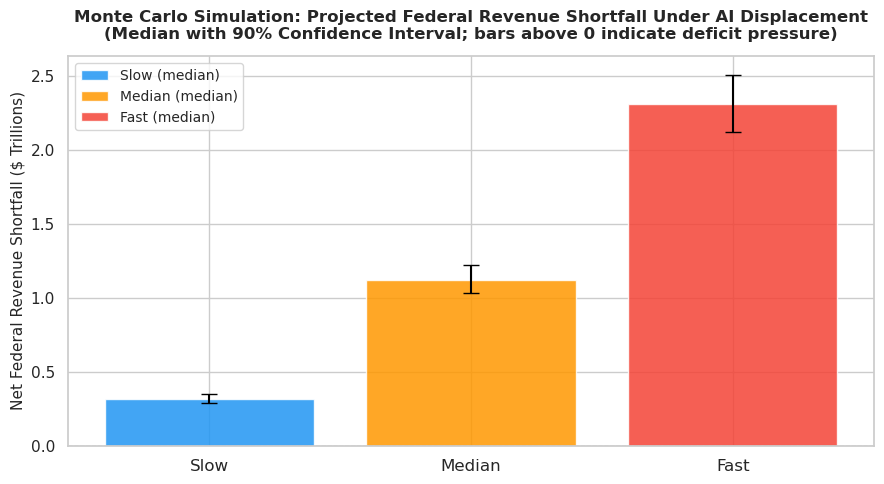

Figure 1 saved.


In [27]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 5))

timeline_order = ["Slow", "Median", "Fast"]
colors = {"Slow": "#2196F3", "Median": "#FF9800", "Fast": "#F44336"}

for i, tl in enumerate(timeline_order):
    row = df_federal_results[df_federal_results["timeline"] == tl].iloc[0]
    median_t  = row["shortfall_p50"]  / 1e12
    p5_t      = row["shortfall_p5"]   / 1e12
    p95_t     = row["shortfall_p95"]  / 1e12

    ax.bar(i, median_t, color=colors[tl], alpha=0.85, label=f"{tl} (median)")
    ax.errorbar(
        i, median_t,
        yerr=[[median_t - p5_t], [p95_t - median_t]],
        fmt="none", color="black", capsize=6, linewidth=1.5,
        label="_nolegend_"
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(range(len(timeline_order)))
ax.set_xticklabels(timeline_order, fontsize=12)
ax.set_ylabel("Net Federal Revenue Shortfall ($ Trillions)", fontsize=11)
ax.set_title(
    "Monte Carlo Simulation: Projected Federal Revenue Shortfall Under AI Displacement\n"
    "(Median with 90% Confidence Interval; bars above 0 indicate deficit pressure)",
    fontsize=12, weight="bold", pad=12
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_fig1_federal_shortfall_by_timeline.png"), dpi=150)
plt.show()
print("Figure 1 saved.")

### Figure 2: Industry-level median shortfall — Fast timeline, sorted descending

<BarContainer object of 19 artists>

Text(0.5, 0, 'Median Net Revenue Shortfall ($ Billions)')

Text(0.5, 1.0, 'Industry-Level Projected Federal Revenue Shortfall — Fast AI Adoption Timeline\n(Median across Monte Carlo draws; red = structural deficit-trap risk)')

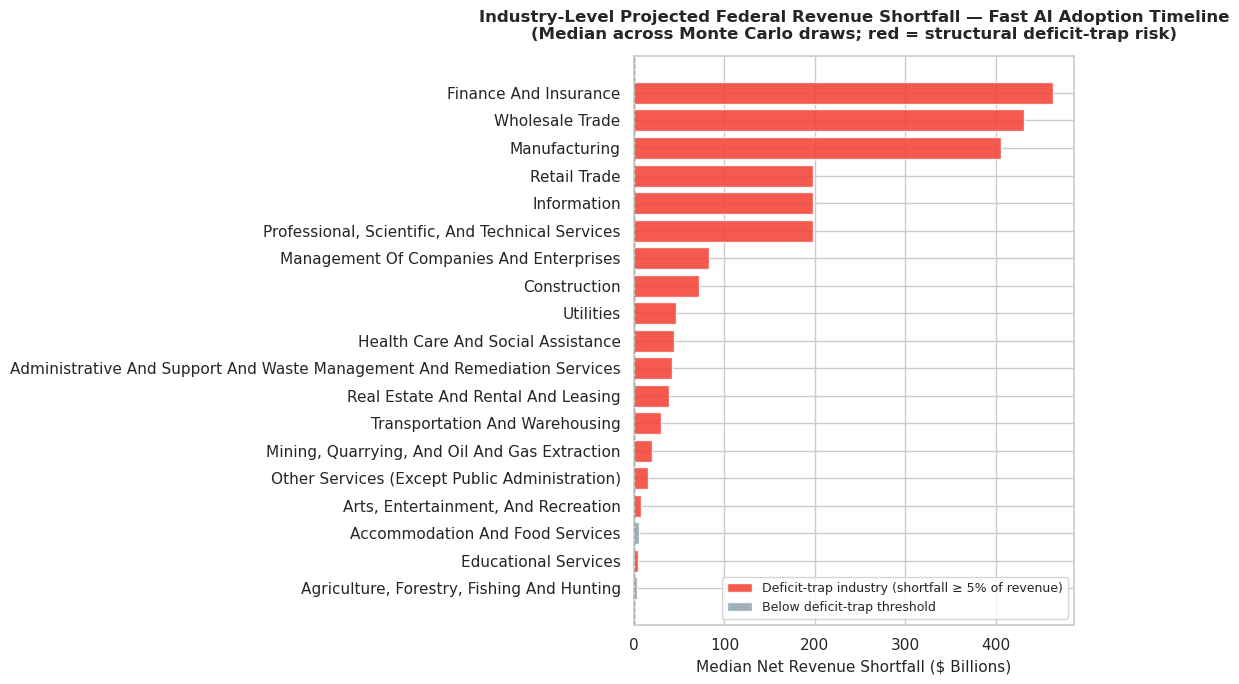

Figure 2 saved.


In [28]:
fast_df = (
    df_industry_results[df_industry_results["timeline"] == "Fast"]
    .sort_values("shortfall_p50", ascending=True)
    .copy()
)
fast_df["shortfall_p50_B"] = fast_df["shortfall_p50"] / 1e9   # convert to billions

fig, ax = plt.subplots(figsize=(11, 7))

bar_colors = np.where(fast_df["deficit_trap"] == 1, "#F44336", "#90A4AE")

ax.barh(
    fast_df[COL_INDUSTRY],
    fast_df["shortfall_p50_B"],
    color=bar_colors,
    alpha=0.88
)
ax.axvline(0, color="black", linewidth=0.9, linestyle="--")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#F44336", alpha=0.88, label=f"Deficit-trap industry (shortfall ≥ {DEFICIT_TRAP_THRESHOLD*100:.0f}% of revenue)"),
    Patch(facecolor="#90A4AE", alpha=0.88, label="Below deficit-trap threshold"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="lower right")

ax.set_xlabel("Median Net Revenue Shortfall ($ Billions)", fontsize=11)
ax.set_title(
    "Industry-Level Projected Federal Revenue Shortfall — Fast AI Adoption Timeline\n"
    "(Median across Monte Carlo draws; red = structural deficit-trap risk)",
    fontsize=12, weight="bold", pad=12
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_fig2_industry_shortfall_fast.png"), dpi=150)
plt.show()
print("Figure 2 saved.")

### Figure 3: Simulation distribution — shortfall probability density per timeline (federal total)

Text(0.5, 0, 'Federal Net Revenue Shortfall ($ Trillions)')

Text(0, 0.5, 'Probability Density')

Text(0.5, 1.0, 'Monte Carlo Simulation: Distribution of Federal Revenue Shortfall by AI Adoption Timeline\n(N = 100,000 iterations; mass right of zero = net fiscal deficit pressure)')

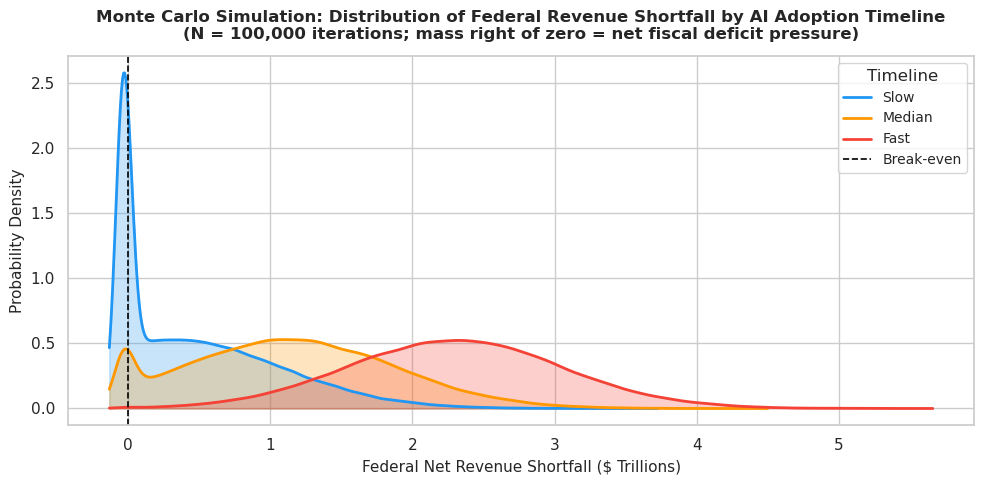

Figure 3 saved.


In [29]:
# Re-run a federal-level simulation to get the full distribution for plotting
# (aggregate industry point estimates; apply noise at federal level for KDE)
# scipy KDE — replaces sns.kdeplot, which calls pd.option_context('mode.use_inf_as_null')
# that option was removed in pandas 2.0.  scipy has no pandas dependency.
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(10, 5))

for timeline_label, loss_rate_col in TIMELINE_COLS.items():
    # Weighted-sum income loss rate (wage-weighted across industries)
    total_wage_labor_rev = df_sectors["baseline_labor_rev"].sum()
    weights = df_sectors["baseline_labor_rev"] / total_wage_labor_rev
    federal_point_rate = (df_sectors[loss_rate_col] * weights).sum()

    # Draw N_ITERATIONS federal-level noisy rates
    noisy_rates = np.clip(
        np.random.normal(federal_point_rate, NOISE_STD, N_ITERATIONS), 0, 1
    )
    federal_shortfall_dist = (
        total_wage_labor_rev * noisy_rates
        - df_sectors["baseline_corp_rev"].sum() * CORP_GROWTH_RATE
    ) / 1e12   # trillions



    kde    = gaussian_kde(federal_shortfall_dist, bw_method="scott")
    x_vals = np.linspace(federal_shortfall_dist.min() - 0.1,
                         federal_shortfall_dist.max() + 0.1, 500)
    density = kde(x_vals)

    ax.plot(x_vals, density,
            color=colors[timeline_label], linewidth=2, label=timeline_label)
    ax.fill_between(x_vals, density, alpha=0.25, color=colors[timeline_label])


ax.axvline(0, color="black", linewidth=1.2, linestyle="--", label="Break-even")
ax.set_xlabel("Federal Net Revenue Shortfall ($ Trillions)", fontsize=11)
ax.set_ylabel("Probability Density", fontsize=11)
ax.set_title(
    "Monte Carlo Simulation: Distribution of Federal Revenue Shortfall by AI Adoption Timeline\n"
    f"(N = {N_ITERATIONS:,} iterations; mass right of zero = net fiscal deficit pressure)",
    fontsize=12, weight="bold", pad=12
)
ax.legend(title="Timeline", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_fig3_shortfall_kde_by_timeline.png"), dpi=150)
plt.show()
print("Figure 3 saved.")

## 8. Summary diagnostics

In [30]:
print("=" * 60)
print("SIMULATION SUMMARY")
print("=" * 60)

for _, row in df_federal_results.iterrows():
    tl    = row["timeline"]
    med   = row["shortfall_p50"] / 1e12
    p5    = row["shortfall_p5"]  / 1e12
    p95   = row["shortfall_p95"] / 1e12
    pct   = row["shortfall_pct_of_rev"] * 100
    n_dt  = int(row["n_deficit_trap_industries"])
    n_ind = int(row["n_industries"])

    print(f"\n  Timeline : {tl}")
    print(f"    Median shortfall       : ${med:.2f}T  (90% CI: ${p5:.2f}T – ${p95:.2f}T)")
    print(f"    Shortfall % of revenue : {pct:.1f}%")
    print(f"    Deficit-trap industries: {n_dt} of {n_ind}")

    if pct >= DEFICIT_TRAP_THRESHOLD * 100:
        print(f"    *** STRUCTURAL DEFICIT TRAP THRESHOLD EXCEEDED ***")

print("\n" + "=" * 60)
print("Output files:")
print(f"  {industry_out_path}")
print(f"  {federal_out_path}")
print("  output/03_fig1_federal_shortfall_by_timeline.png")
print("  output/03_fig2_industry_shortfall_fast.png")
print("  output/03_fig3_shortfall_kde_by_timeline.png")

SIMULATION SUMMARY

  Timeline : Slow
    Median shortfall       : $0.32T  (90% CI: $0.29T – $0.35T)
    Shortfall % of revenue : 2.0%
    Deficit-trap industries: 1 of 19

  Timeline : Median
    Median shortfall       : $1.12T  (90% CI: $1.03T – $1.22T)
    Shortfall % of revenue : 7.0%
    Deficit-trap industries: 11 of 19
    *** STRUCTURAL DEFICIT TRAP THRESHOLD EXCEEDED ***

  Timeline : Fast
    Median shortfall       : $2.31T  (90% CI: $2.12T – $2.51T)
    Shortfall % of revenue : 14.3%
    Deficit-trap industries: 17 of 19
    *** STRUCTURAL DEFICIT TRAP THRESHOLD EXCEEDED ***

Output files:
  output/03_simulation_results.csv
  output/03_deficit_trap_summary.csv
  output/03_fig1_federal_shortfall_by_timeline.png
  output/03_fig2_industry_shortfall_fast.png
  output/03_fig3_shortfall_kde_by_timeline.png
